In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
from fontTools.merge import cmap

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

from dfmodel import DigitalFamilyBinary

In [37]:
training_data = pd.read_csv(
    "../tests/data/design_matrix_train.tsv",
    sep="\t"
)

In [38]:
testing_data = pd.read_csv(
    "../tests/data/design_matrix_test.tsv",
    sep="\t"
)

In [39]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [40]:
clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])


In [42]:
training_data[clinical_columns]

,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,crp_day1,trc_emergency_department,sex,age
0,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,-2.677143e-16,-0.345625,-0.906163,1.0,-2.365415
1,-1.577464,-0.128251,0.216787,0.322727,1.041185,1.0,-1.451047,-0.037510,-2.677143e-16,-0.434355,1.385753,0.0,-0.075467
2,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,-2.677143e-16,0.679707,0.384794,1.0,-0.155328
3,-1.008986,0.483898,-0.784273,-0.434471,-0.992900,1.0,-0.183094,-0.026722,-2.677143e-16,1.665603,-0.859389,0.0,1.115809
4,-0.213116,-1.597408,-1.611235,0.394841,1.940465,1.0,-3.109139,-0.188534,-8.225653e-01,-0.953922,0.160279,0.0,-2.188787
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,0.810144,1.096046,-0.740748,-0.542642,-0.714552,1.0,-1.255977,-0.350345,-2.677143e-16,-0.158304,3.874118,1.0,0.295378
676,0.127971,-0.128251,-0.436078,0.539069,0.998362,1.0,0.207045,-0.673968,3.077577e-01,-0.808996,0.712210,0.0,0.009216
677,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,-2.197263e-01,-0.345625,1.900264,1.0,0.058323
678,0.469057,0.606327,-0.523127,-0.722927,0.000000,2.0,0.304580,-0.663181,-5.965007e-01,-0.207599,0.188344,0.0,0.413090


<Axes: >

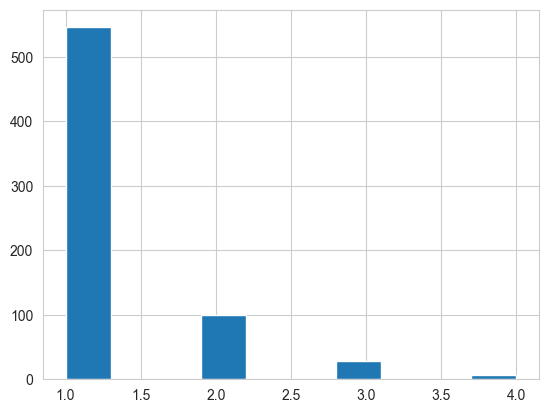

In [43]:
training_data["mental_status_ambulance"].hist()

In [44]:
df_estimator = DigitalFamilyBinary(n_neighbors=5, neighbor_metric="euclidean")

In [45]:
df_estimator.fit(training_data, features=clinical_columns)

In [46]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


100%|██████████| 1000/1000 [00:01<00:00, 545.01it/s]

BarnesHut Approximation  took  0.43  seconds
Repulsion forces  took  1.22  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.01  seconds
AdjustSpeedAndApplyForces step  took  0.09  seconds


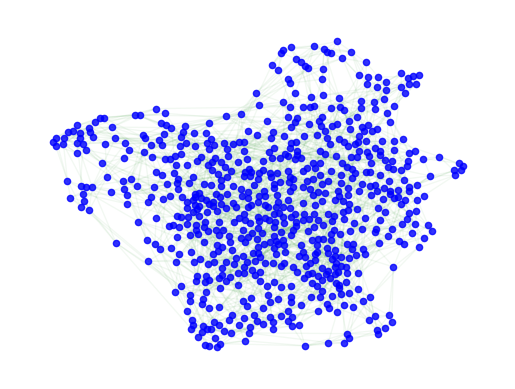

In [47]:
forceatlas2 = ForceAtlas2(
                        # Behavior alternatives
                        outboundAttractionDistribution=True,  # Dissuade hubs
                        linLogMode=False,  # NOT IMPLEMENTED
                        adjustSizes=False,  # Prevent overlap (NOT IMPLEMENTED)
                        edgeWeightInfluence=1.0,

                        # Performance
                        jitterTolerance=1.0,  # Tolerance
                        barnesHutOptimize=True,
                        barnesHutTheta=1.2,
                        multiThreaded=False,  # NOT IMPLEMENTED

                        # Tuning
                        scalingRatio=2.0,
                        strongGravityMode=False,
                        gravity=1.0,

                        # Log
                        verbose=True)

positions = forceatlas2.forceatlas2_networkx_layout(G, pos=None, iterations=1000)
nx.draw_networkx_nodes(G, positions, node_size=20, node_color="blue", alpha=0.8)
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

In [48]:
training_data['mortality_30_day'] = np.where(training_data['survival_days'] <= 30, 1, 0)

In [49]:
training_data['mortality_30_day'].value_counts()

mortality_30_day
0    611
1     69
Name: count, dtype: int64

In [53]:

color_map = dict(zip(training_data.index, training_data['sex']))

node_colors = [color_map[node] for node in G.nodes()]


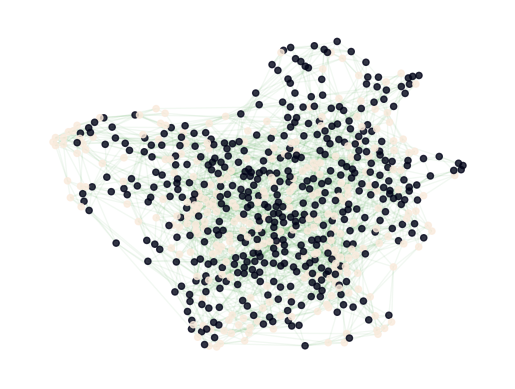

In [54]:
nx.draw_networkx_nodes(G, positions, node_size=20, node_color=node_colors, alpha=0.8,)
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

In [52]:
for idx, data in testing_data.iterrows():

    sample_graph = df_estimator.model_sample(data, clinical_columns)

In [17]:
sample_graph

In [18]:
X_ = training_data.copy()
X_['source'] = "base"
X_['size'] = 20

test = pd.DataFrame([data])
test['source'] = "query"
test['size'] = 100

In [19]:
combined_data = pd.concat(
    [X_, test], ignore_index=True
)

In [20]:
combined_data.tail()

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_coag_day3,sofa_cns_day1,sofa_cns_day2,sofa_cns_day3,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,mortality_30_day,source,size
676,676,SA_BOX_3-697_S4-A6_1_5555,0.127971,-0.128251,-0.436078,0.539069,0.998362,1.0,0.207045,-0.673968,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,base,20
677,677,SA_BOX_8-2367_S5-C12_1_6096,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,base,20
678,678,SA_BOX_4-2564_S5-F11_1_5699,0.469057,0.606327,-0.523127,-0.722927,0.000000,2.0,0.304580,-0.663181,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,base,20
679,679,SA_BOX_10-131_S2-H6_1_6249,-0.440508,0.116608,-0.131408,-0.903212,0.000000,1.0,1.182393,-0.253258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,base,20
680,679,SA_BOX_4-1196_S5-A2_1_5621,0.469057,0.116608,-0.784273,3.063060,2.925391,1.0,0.597184,-0.156171,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,query,100


In [21]:
nx.set_node_attributes(sample_graph, combined_data.to_dict(orient="index"))

In [22]:
sample_graph.nodes[0]

{'Unnamed: 0': 0,
 'injection': 'SA_BOX_1-462_S1-C8_1_6848',
 'sao2_ambulance': -0.44050753352931954,
 'resp_frequency_ambulance': -0.8628294945851923,
 'heart_rate_ambulance': 0.34736017417729576,
 'syst_bp_ambulance': -0.18207167917904263,
 'map_ambulance': 0.2703738643250759,
 'mental_status_ambulance': 1.0,
 'temperature_ambulance': 0.6947192322208972,
 'crea_emergency_department': -0.5553062518845568,
 'bili_emergency_department': -2.6771426586197504e-16,
 'crp_day1': -0.34562459386468325,
 'trc_emergency_department': -0.9061630549118384,
 'sex': 2.0,
 'age': -2.3654152369787647,
 'diagnosis_sepsis_student_3': 4.0,
 'sepsis_or_septic_shock': 1.0,
 'survival_days': nan,
 'sofa_score_increase_day1': 2.0,
 'sofa_score_increase_day2': nan,
 'sofa_score_increase_day3': nan,
 'verified_infection': 1.0,
 'no_infection': 0.0,
 'irrelevante_bacteremia': 0.0,
 'blood_culture_positive': 0.0,
 'urinary_tract_infection': 0.0,
 'abdominal_infection': 0.0,
 'pseud_blood_culture': 0.0,
 'k_pneu_b

100%|██████████| 1000/1000 [00:01<00:00, 565.66it/s]

BarnesHut Approximation  took  0.41  seconds
Repulsion forces  took  1.16  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.01  seconds
AdjustSpeedAndApplyForces step  took  0.10  seconds


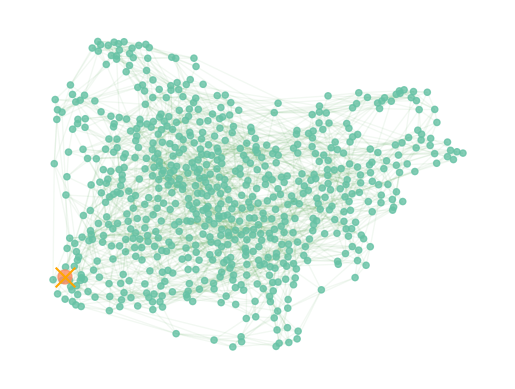

In [23]:
forceatlas2 = ForceAtlas2(
                        # Behavior alternatives
                        outboundAttractionDistribution=True,  # Dissuade hubs
                        linLogMode=False,  # NOT IMPLEMENTED
                        adjustSizes=False,  # Prevent overlap (NOT IMPLEMENTED)
                        edgeWeightInfluence=1.0,

                        # Performance
                        jitterTolerance=1.0,  # Tolerance
                        barnesHutOptimize=True,
                        barnesHutTheta=1.2,
                        multiThreaded=False,  # NOT IMPLEMENTED

                        # Tuning
                        scalingRatio=2.0,
                        strongGravityMode=False,
                        gravity=1.0,

                        # Log
                        verbose=True)

categories = combined_data['source'].unique()
palette = sns.color_palette('Set2', n_colors=len(categories))
category_color_map = dict(zip(categories, palette))

node_colors = [category_color_map[sample_graph.nodes[node]['source']] for node in sample_graph.nodes]

positions = forceatlas2.forceatlas2_networkx_layout(sample_graph, pos=None, iterations=1000)
nx.draw_networkx_nodes(sample_graph, positions, node_size=combined_data['size'].to_list(), node_color=node_colors, alpha=0.8)

nx.draw_networkx_nodes(sample_graph, positions,
                       nodelist=[680],
                       node_size=200,
                       node_color='orange',
                       node_shape='x')

nx.draw_networkx_edges(sample_graph, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()